In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dtw import *

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
def get_data(df, row_name):
    data = []

    for i, row in df.iterrows():
        if not pd.isna(row[row_name]):
            data.append([i,row[row_name]])

    return np.asarray(data)    

In [3]:
xl_file = pd.ExcelFile('I_full data.xlsx')

dfs = {sheet_name: xl_file.parse(sheet_name) 
          for sheet_name in xl_file.sheet_names}

In [6]:
dfs['B'].columns

Index(['thickness, mm', 'Piece', 'sample №', 'thick, mm', 'weight, g',
       'Vol, cm3', 'depth, mm', 'Dgeo', 'Igeo', 'MADgeo', 'NRMmax (Am2/kg)',
       'ARMmax (Am2/kg)'],
      dtype='str')

In [56]:
sheet_B = dfs['A']

In [57]:
sheet_C = dfs['C']

In [63]:
sample_1 = get_data(sheet_B, 'Igeo')
sample_2 = get_data(sheet_C, 'Igeo')

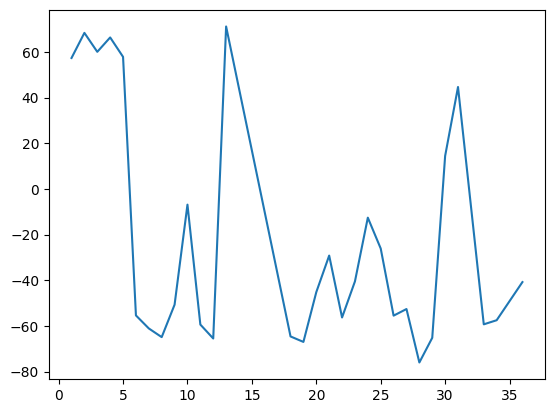

In [64]:
plt.plot(sample_1[:,0],sample_1[:,1])

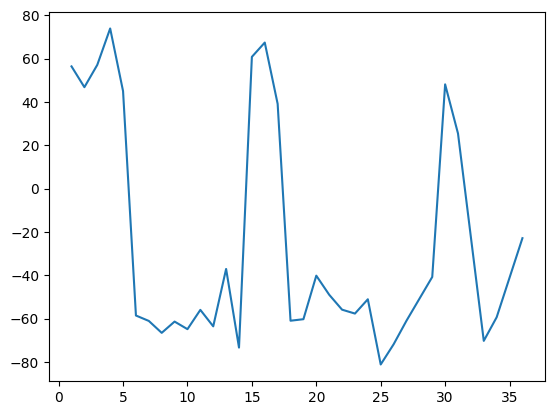

In [65]:
plt.plot(sample_2[:,0],sample_2[:,1])

In [ ]:
alignment = dtw(
    sample_1[:, 1],
    sample_2[:, 1],
    keep_internals=True,
    step_pattern=asymmetric,
    open_begin=True,
    open_end=True
)

alignment.plot(type="threeway")

## Align and plot with the Rabiner-Juang type VI-c unsmoothed recursion
dtw(sample_1[:,1], sample_2[:,1], keep_internals=True, 
    step_pattern=rabinerJuangStepPattern(type,slope_weighting="d",smoothed=False))\
    .plot(type="twoway", offset = 160)

TypeError: rabinerJuangStepPattern.<locals>.<lambda>() takes 0 positional arguments but 2 were given

Step pattern recursion:
 g[i,j] = min(
     g[i-2,j-1] +     d[i-1,j  ] +     d[i  ,j  ] ,
     g[i-1,j-1] +     d[i  ,j  ] ,
     g[i-1,j-2] +     d[i  ,j-1] +     d[i  ,j  ] ,
 ) 

Normalization hint: NA



<Axes: xlabel='Query index', ylabel='Reference index'>

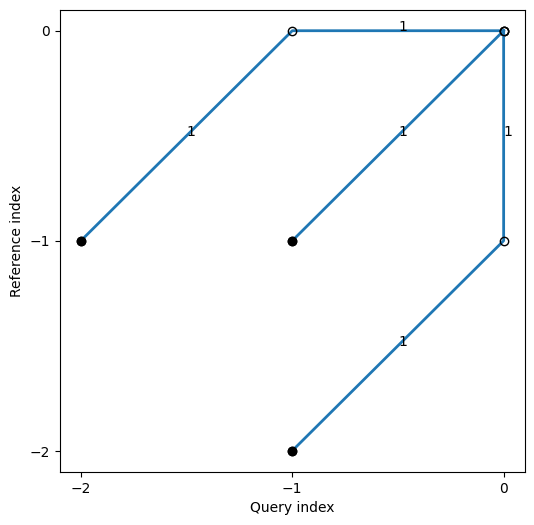

In [82]:
print(typeIb)
typeIb.plot()